# **5. El algoritmo Clustering**

Para entender qué hace y cómo funciona el algoritmo de inteligencia artificial clustering, entendamos el tipo de tarea o problema que queremos resolver. Imagínate que queremos sustituir a un jugador de nuestro equipo o hemos perdido  a un jugador y queremos fichar otro jugador similar o simplemente queremos fichar un jugador. Nosotros con conocimiento sobre el deporte, en este caso de baloncesto, tiraremos de nuestra experiencia para buscar otros jugadores, en función de sus características y estadísticas. Que sean lo más parecido al jugador que queremos sustituir. También podemos ser un equipo que juega de una determinada manera y buscamos jugadores que puedan encajar bien. ¿Cómo nos ayuda el algoritmo de clustering para este problema?

Como ya he dicho, nosotros si conocemos el deporte, podemos usar nuestro conocimiento, para de una  manera intuitiva buscar al jugador perfecto para el puesto. Esta función es de la que se encarga el algoritmo de Machine Learning, Clustering. A través de todas las métricas de los jugadores, es capaz de realizar agrupaciones de jugadores, encontrando patrones en sus datos. 

Por ejemplo, nosotros sabemos que pueden existir dos tipos de bases, uno más anotador y otro más pasador. El algoritmo clustering, será capaz de detectar estos patrones y realizar agrupaciones, detectando los bases más pasadores y anotadores.

Esto es muy útil en la era del big data, ya que las métricas o datos que se pueden extraer de un jugador son enormes. De las cuales, se pueden extraer patrones que  nuestro ojo humano no es capaz de percibir. Cuantos más datos tengamos, que nos de información del jugador, más precisa serán las agrupaciones. También estamos en un mundo globalizado con muchas ligas profesionales. Si fuéramos un equipo de la NBA, no solo buscaríamos el jugador en la propia liga, sino también en la liga  universitaria NCAA, en ligas europeas como la ACB, LNB, etc  y cualquier liga profesional del mundo con buen nivel competitivo como la NBL, que es la liga Australiana de baloncesto. Como vemos son muchos datos y muchos jugadores, por eso la necesidad de un algoritmo, que sea capaz de decirte el jugador que mejor se adapte a lo que buscas, con un simple click.




# 5.1. Entendiendo el algoritmo de clustering Kmeans
Ahora pasaré a explicarte, la idea intuitiva detrás del funcionamiento del algoritmo de Clustering. Hay diferentes tipos de algoritmos clustering, en este caso hablaremos del algoritmo Kmeans y de cómo es posible que pueda dar solución a este problema. 

En la imagen, podemos ver a la izquierda, la representación gráfica de los datos y a la derecha, el resultado al aplicar kmeans. 


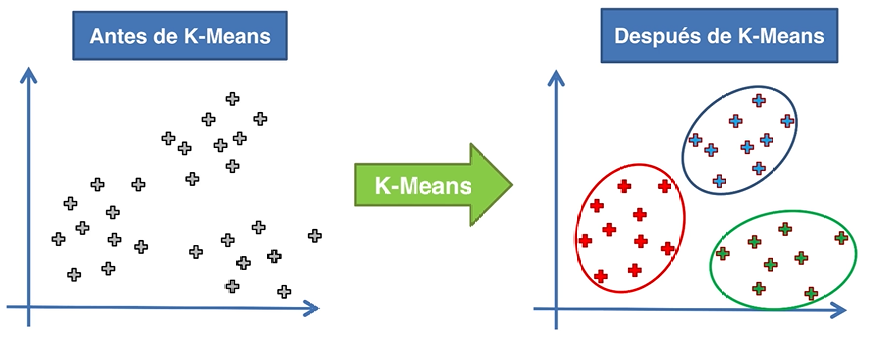

Podemos ver cómo hemos pasado de una nube de puntos, a tres agrupaciones, a través de encontrar patrones en ellos y calcular distancias entre los datos. Estas tres agrupaciones comparten características similares, que nos aportan información de los tres clusters.

Visualmente como humanos, podemos ver en el gráfica 2D que existen tres agrupaciones en los datos, pero en la vida real no tendremos sólo dos variables que analizar. Si analizamos tres variables, al graficarlas sería un gráfico en 3D, a partir de ahí, nosotros como humanos no somos capaces de interpretar los datos más allá de las tres dimensiones. Vamos a trabajar con datasets que tienen decenas de variables y tendremos una dimensión por cada variable, por lo que serán un montón de dimensiones. Es ahí donde el algoritmo de Kmeans, nos ayuda a encontrar patrones en los datos para crear agrupaciones.

El cómo es posible que el algoritmo Kmeans realice la agrupación, es con un enfoque simple, que consiste en calcular distancias entres los datos, a través de geometría básica. Al centro geométrico del  cluster se le llama centroide, a partir de la distancia de los datos a  los centroides es como se determina qué datos pertenecen a qué cluster.

Iniciamos de manera aleatoria los centroides  en dos puntos cualesquiera del gráfico.

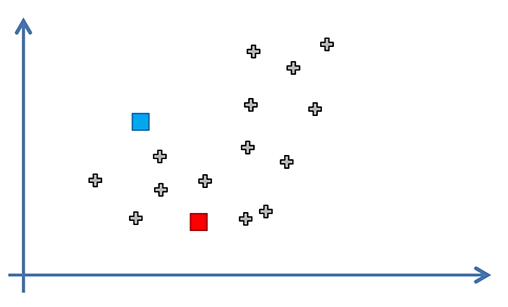

Una vez tenemos los dos centroides, tenemos que ver qué puntos del gráfico están más cerca de cada centroide. Para saber cual esta mas cerca, utilizaremos  un truco de geometría, uniremos con una línea recta los dos centroides y después trazaremos la mediatriz, que es una recta que corte por la mitad dicha línea.

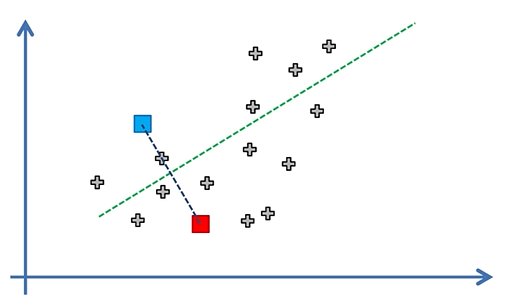

Los valores por encima de la recta, estarán más cercanos al centroide azul y por debajo, al rojo. Ahora ya tenemos los dos clusters.

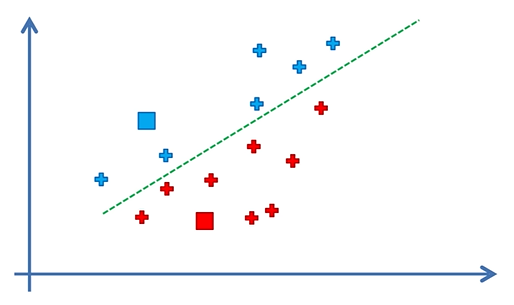

Con los dos nuevos clusters creados, a través de los centroides iniciados aleatoriamente, calculamos la media geométrica de cada cluster. El resultado de la media geométrica de cada cluster, será la nueva posición de los centroides. 

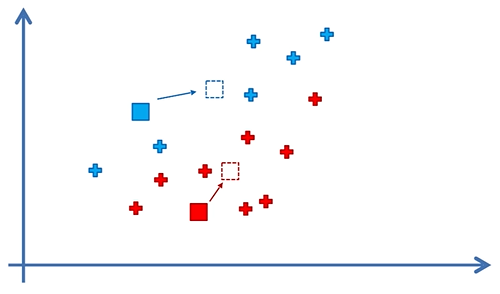

Una vez recalculada la nueva posición de los centroides, volvemos a calcular la distancia entre ellos, para ver qué datos están más cerca de cada centroide.

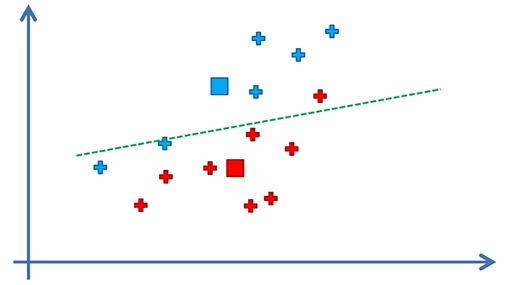

Podemos ver que con los nuevos centroides, hay un dato del cluster rojo que ha quedado por encima de la recta, por lo tanto el dato cambiará al clúster azul.

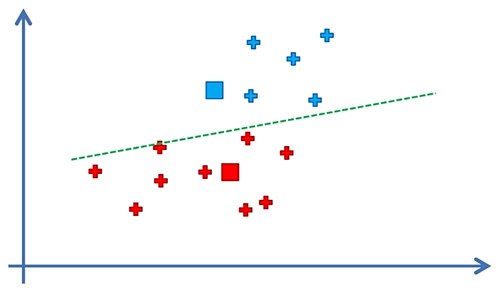

Ahora que ya tenemos los nuevos clusters correctamente,  volveremos a realizar el mismo proceso de calcular la media geométrica de nuestros nuevos clusters, para calcular de nuevo los centroides. 

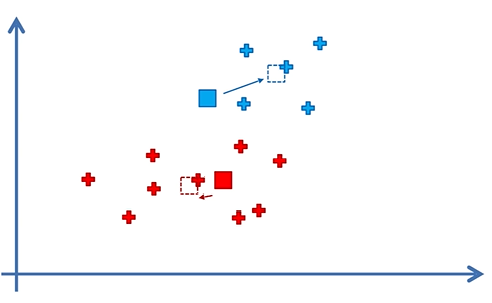

Este proceso se repetirá, hasta el punto que no se produzca una corrección en los datos para cambiar de cluster. Querrá decir, que no hay más cambios en los clusters y que el algoritmo ha finalizado su tarea de agrupar los datos. Este será el resultado final.

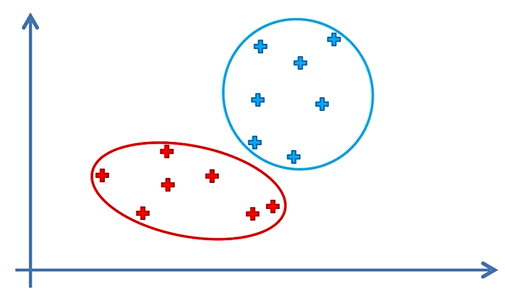

# 5.2. Aplicar Kmeans a una mátrica
Importamos las librerías que necesitaremos durante el proceso. 


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy
import sys

Añadimos con sys el path hasta la carpeta Functions, donde se encuentran nuestras propias librerías que creamos durante el curso. 

In [3]:
sys.path.append('/content/drive/MyDrive/Mi curso/Functions')

Importamos transformBR que contiene funciones para el tratamiento de los datos de la NBA, de la página web Basketball Reference.

In [4]:
import transformBR as br

Una vez importada nuestras funciones como una librería, accedemos a través de punto a la función trasnform_data_all_players_bf() para tener los datos listos para el análisis. Utilizaremos la url que contiene las estadísticas por partido, de todos los jugadores de la NBA de la temporada 2021.

In [5]:
url = 'https://www.basketball-reference.com/leagues/NBA_2021_per_game.html'
df = br.transform_data_all_players_bf(url)
df.head()

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Precious Achiuwa,PF,21,MIA,61,4,12.1,2.0,3.7,0.544,0.0,0.0,0.000,2.0,3.7,0.546,0.544,0.9,1.8,0.509,1.2,2.2,3.4,0.5,0.3,0.5,0.7,1.5,5.0
1,Jaylen Adams,PG,24,MIL,7,0,2.6,0.1,1.1,0.125,0.0,0.3,0.000,0.1,0.9,0.167,0.125,0.0,0.0,NaN,0.0,0.4,0.4,0.3,0.0,0.0,0.0,0.1,0.3
2,Steven Adams,C,27,NOP,58,58,27.7,3.3,5.3,0.614,0.0,0.1,0.000,3.3,5.3,0.620,0.614,1.0,2.3,0.444,3.7,5.2,8.9,1.9,0.9,0.7,1.3,1.9,7.6
3,Bam Adebayo,C,23,MIA,64,64,33.5,7.1,12.5,0.570,0.0,0.1,0.250,7.1,12.4,0.573,0.571,4.4,5.5,0.799,2.2,6.7,9.0,5.4,1.2,1.0,2.6,2.3,18.7
4,LaMarcus Aldridge,C,35,TOT,26,23,25.9,5.4,11.4,0.473,1.2,3.1,0.388,4.2,8.3,0.505,0.525,1.6,1.8,0.872,0.7,3.8,4.5,1.9,0.4,1.1,1.0,1.8,13.5


Una vez tenemos los datos con los que vamos a trabajar, vamos a importar el algoritmo Kmeans, de la librería sklearn, que es la librería especializada en Machine Learning. De la cual podemos importar un montón de algoritmos.

In [6]:
from sklearn.cluster import KMeans

## 5.2.1. Encontrar patrones en función de los minutos de juego

Una vez importado el algoritmo Kmeans, lo guardamos en la variable cluster especificando el número de clusters. De esta manera el algoritmo nos hará 5 diferentes agrupaciones en los datos. Con el parámetro random_state=1 tendremos la misma aleatoriedad para tener el mismo resultado.



In [7]:
cluster = KMeans(random_state=1, n_clusters=5)

Una vez creado el modelo, con el método .fit() le pasaremos por parámetro la metrica por la cual queremos que el algoritmo nos encuentre 5 tipos de jugadores en función de los minutos.

In [8]:
cluster.fit(df[['MP']])

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=5, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=1, tol=0.0001, verbose=0)

En un simple click el algoritmo acaba de extraer los patrones de los datos. Con el atributo .labels_ podemos acceder a los diferentes clusters que ha asociado a cada jugador, en función de la cantidad de minutos de juego.

In [9]:
cluster.labels_

array([0, 3, 2, 1, 2, 3, 2, 2, 1, 4, 2, 1, 3, 0, 2, 2, 1, 0, 2, 4, 2, 1,
       3, 2, 2, 1, 1, 4, 2, 1, 1, 1, 3, 2, 4, 4, 1, 1, 1, 0, 4, 2, 2, 2,
       3, 2, 0, 4, 4, 1, 3, 1, 1, 3, 3, 0, 0, 1, 2, 3, 2, 4, 3, 4, 1, 1,
       3, 2, 1, 2, 1, 2, 4, 1, 4, 2, 4, 2, 1, 2, 1, 0, 2, 1, 3, 3, 2, 2,
       3, 0, 1, 3, 0, 2, 2, 4, 4, 0, 0, 4, 2, 2, 4, 0, 1, 1, 2, 3, 0, 4,
       1, 4, 2, 0, 1, 1, 3, 1, 0, 4, 4, 0, 4, 1, 0, 2, 0, 4, 2, 1, 1, 4,
       3, 4, 2, 2, 2, 3, 0, 1, 1, 0, 3, 4, 2, 1, 2, 0, 4, 3, 4, 3, 3, 3,
       0, 1, 3, 4, 4, 0, 1, 1, 0, 0, 2, 0, 0, 2, 0, 1, 4, 4, 1, 4, 0, 1,
       3, 4, 1, 0, 2, 1, 1, 1, 2, 1, 4, 0, 2, 0, 2, 3, 1, 3, 1, 0, 4, 4,
       2, 1, 4, 3, 2, 2, 0, 1, 1, 0, 1, 0, 3, 4, 2, 1, 4, 4, 1, 1, 2, 4,
       3, 4, 4, 1, 1, 0, 1, 4, 2, 4, 2, 4, 3, 1, 3, 1, 0, 2, 4, 0, 2, 1,
       1, 0, 4, 2, 2, 4, 2, 0, 1, 4, 4, 2, 0, 0, 2, 4, 2, 4, 4, 1, 0, 2,
       0, 3, 4, 2, 2, 3, 4, 2, 4, 0, 2, 3, 0, 0, 4, 0, 3, 1, 4, 4, 4, 1,
       0, 3, 3, 4, 4, 4, 1, 0, 1, 4, 1, 0, 4, 2, 4,

Vamos a crear la columna ``'cluster'`` dentro del dataframe, para poder analizar las características de cada cluster.

In [ ]:
df['cluster'] = cluster.labels_

Ahora con la columna cluster,  podremos realizar una agrupación y extraer el promedio de minutos, para ver la cantidad de minutos de juego de cada cluster.

In [ ]:
df.groupby(['cluster'])['MP'].mean().sort_values(ascending=False)

cluster
1    32.252893
2    25.094595
4    18.340876
0    11.730435
3     5.358228
Name: MP, dtype: float64

Podemos ver la cantidad de minutos promedio de cada cluster y entender la información de cada cluster. Si nos fijamos, en el cluster 1, se encuentran los jugadores top que juegan más minutos. Podemos filtrar los datos para ver qué jugadores son. 

In [ ]:
df[df.cluster == 1]

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
3,Bam Adebayo,C,23,MIA,64,64,33.5,7.1,12.5,0.570,0.0,0.1,0.250,7.1,12.4,0.573,0.571,4.4,5.5,0.799,2.2,6.7,9.0,5.4,1.2,1.0,2.6,2.3,18.7,1
10,Jarrett Allen,C,22,TOT,63,45,29.6,4.7,7.7,0.618,0.1,0.3,0.316,4.6,7.3,0.631,0.624,3.2,4.6,0.703,3.1,6.9,10.0,1.7,0.5,1.4,1.6,1.5,12.8,1
17,Giannis Antetokounmpo,PF,26,MIL,61,61,33.0,10.3,18.0,0.569,1.1,3.6,0.303,9.2,14.4,0.636,0.600,6.5,9.5,0.685,1.6,9.4,11.0,5.9,1.2,1.2,3.4,2.8,28.1,1
22,OG Anunoby,SF,23,TOR,43,43,33.3,5.8,12.1,0.480,2.4,6.1,0.398,3.4,6.0,0.562,0.580,1.9,2.4,0.784,1.3,4.3,5.5,2.2,1.5,0.7,1.7,2.7,15.9,1
30,Deandre Ayton,C,22,PHO,69,69,30.7,6.2,10.0,0.626,0.1,0.3,0.200,6.2,9.7,0.639,0.629,1.9,2.5,0.769,3.3,7.2,10.5,1.4,0.6,1.2,1.5,2.8,14.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,Derrick White,SG,26,SAS,36,32,29.6,5.2,12.6,0.411,2.3,6.8,0.346,2.8,5.8,0.486,0.503,2.7,3.2,0.851,0.4,2.6,3.0,3.5,0.7,1.0,1.3,2.5,15.4,1
706,Andrew Wiggins,PF,25,GSW,71,71,33.3,7.1,14.9,0.477,2.0,5.2,0.380,5.1,9.7,0.529,0.543,2.4,3.4,0.714,1.2,3.7,4.9,2.4,0.9,1.0,1.8,2.2,18.6,1
714,Zion Williamson,PF,20,NOP,61,61,33.2,10.4,17.0,0.611,0.2,0.6,0.294,10.2,16.4,0.622,0.616,6.0,8.7,0.698,2.7,4.5,7.2,3.7,0.9,0.6,2.7,2.2,27.0,1
722,Christian Wood,C,25,HOU,41,41,32.3,8.0,15.6,0.514,1.9,5.0,0.374,6.1,10.6,0.581,0.574,3.0,4.8,0.631,1.9,7.8,9.6,1.7,0.8,1.2,2.0,2.1,21.0,1


Podemos ver, como hay nombres importantes y jugadores muy importantes para sus equipos. Vamos a ir más allá en análisis y vamos a filtrar por las bases del cluster 1.

In [ ]:
df[(df.cluster == 1) & (df.Pos == 'PG')]

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
34,LaMelo Ball,PG,19,CHO,51,31,28.8,5.7,13.2,0.436,1.8,5.1,0.352,3.9,8.1,0.489,0.504,2.5,3.2,0.758,1.2,4.7,5.9,6.1,1.6,0.4,2.8,2.7,15.7,1
35,Lonzo Ball,PG,23,NOP,55,55,31.8,5.3,12.7,0.414,3.1,8.3,0.378,2.1,4.5,0.482,0.537,0.9,1.2,0.781,0.6,4.2,4.8,5.7,1.5,0.6,2.2,1.9,14.6,1
92,Malcolm Brogdon,PG,28,IND,56,56,34.5,7.9,17.5,0.453,2.6,6.7,0.388,5.3,10.8,0.493,0.527,2.7,3.2,0.864,1.0,4.2,5.3,5.9,0.9,0.3,2.1,2.0,21.2,1
138,Mike Conley,PG,33,UTA,51,51,29.4,5.6,12.5,0.444,2.7,6.6,0.412,2.9,6.0,0.479,0.552,2.4,2.8,0.852,0.7,2.8,3.5,6.0,1.4,0.2,1.9,1.9,16.2,1
156,Stephen Curry,PG,32,GSW,63,63,34.2,10.4,21.7,0.482,5.3,12.7,0.421,5.1,9.0,0.569,0.605,5.7,6.3,0.916,0.5,5.0,5.5,5.8,1.2,0.1,3.4,1.9,32.0,1
177,Luka Dončić,PG,21,DAL,66,66,34.3,9.8,20.5,0.479,2.9,8.3,0.350,6.9,12.2,0.567,0.550,5.2,7.1,0.730,0.8,7.2,8.0,8.6,1.0,0.5,4.3,2.3,27.7,1
217,De'Aaron Fox,PG,23,SAC,58,58,35.1,9.1,19.1,0.477,1.8,5.5,0.322,7.3,13.6,0.539,0.523,5.2,7.2,0.719,0.6,2.9,3.5,7.2,1.5,0.5,3.0,2.9,25.2,1
227,Darius Garland,PG,21,CLE,54,50,33.1,6.7,14.9,0.451,1.9,4.9,0.395,4.8,9.9,0.479,0.517,2.1,2.4,0.848,0.4,2.0,2.4,6.1,1.2,0.1,3.0,2.0,17.4,1
243,Devonte' Graham,PG,25,CHO,55,44,30.2,4.6,12.2,0.377,3.3,8.7,0.375,1.3,3.5,0.380,0.510,2.4,2.9,0.842,0.4,2.3,2.7,5.4,0.9,0.1,1.5,1.4,14.8,1
259,Tyrese Haliburton,PG,20,SAC,58,20,30.1,5.0,10.7,0.472,2.1,5.1,0.409,2.9,5.6,0.529,0.569,0.8,1.0,0.857,0.7,2.3,3.0,5.3,1.3,0.5,1.6,1.4,13.0,1


Nuevamente vemos los nombres de bases muy importantes. Vamos a ordenar los valores en función de los puntos y mostrar los 10 más anotadores. De esta manera podemos analizar mejor el tipo de cluster.

In [ ]:
df[(df.cluster == 1) & (df.Pos == 'PG')].sort_values('PTS', ascending=False).head(10)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
156,Stephen Curry,PG,32,GSW,63,63,34.2,10.4,21.7,0.482,5.3,12.7,0.421,5.1,9.0,0.569,0.605,5.7,6.3,0.916,0.5,5.0,5.5,5.8,1.2,0.1,3.4,1.9,32.0,1
410,Damian Lillard,PG,30,POR,67,67,35.8,9.0,19.9,0.451,4.1,10.5,0.391,4.9,9.4,0.519,0.554,6.7,7.2,0.928,0.5,3.7,4.2,7.5,0.9,0.3,3.0,1.5,28.8,1
177,Luka Dončić,PG,21,DAL,66,66,34.3,9.8,20.5,0.479,2.9,8.3,0.350,6.9,12.2,0.567,0.550,5.2,7.1,0.730,0.8,7.2,8.0,8.6,1.0,0.5,4.3,2.3,27.7,1
328,Kyrie Irving,PG,28,BRK,54,54,34.9,10.2,20.1,0.506,2.8,7.0,0.402,7.4,13.1,0.561,0.576,3.7,4.0,0.922,1.0,3.8,4.8,6.0,1.4,0.7,2.4,2.6,26.9,1
470,Donovan Mitchell,PG,24,UTA,53,53,33.4,9.0,20.6,0.438,3.4,8.7,0.386,5.7,11.9,0.476,0.520,5.0,6.0,0.845,0.9,3.5,4.4,5.2,1.0,0.3,2.8,2.2,26.4,1
728,Trae Young,PG,22,ATL,63,63,33.7,7.7,17.7,0.438,2.2,6.3,0.343,5.6,11.3,0.491,0.499,7.7,8.7,0.886,0.6,3.3,3.9,9.4,0.8,0.2,4.1,1.8,25.3,1
217,De'Aaron Fox,PG,23,SAC,58,58,35.1,9.1,19.1,0.477,1.8,5.5,0.322,7.3,13.6,0.539,0.523,5.2,7.2,0.719,0.6,2.9,3.5,7.2,1.5,0.5,3.0,2.9,25.2,1
340,LeBron James,PG,36,LAL,45,45,33.4,9.4,18.3,0.513,2.3,6.3,0.365,7.1,12.0,0.591,0.576,4.0,5.7,0.698,0.6,7.0,7.7,7.8,1.1,0.6,3.7,1.6,25.0,1
266,James Harden,PG,31,TOT,44,43,36.6,7.8,16.7,0.466,2.8,7.6,0.362,5.0,9.1,0.553,0.548,6.3,7.3,0.861,0.8,7.1,7.9,10.8,1.2,0.8,4.0,2.3,24.6,1
700,Russell Westbrook,PG,32,WAS,65,65,36.4,8.4,19.0,0.439,1.3,4.2,0.315,7.0,14.8,0.475,0.474,4.2,6.4,0.656,1.7,9.9,11.5,11.7,1.4,0.4,4.8,2.9,22.2,1


De esta manera queda claro que kmeans ha sido capaz de detectar a las superestrellas de la NBA en cluster 1, en función de su importancia por los minutos. Podemos hacer el mismo filtrado pero para el cluster 2.


In [ ]:
df[(df.cluster == 2) & (df.Pos == 'PG')]

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
21,Cole Anthony,PG,20,ORL,47,34,27.1,4.7,11.7,0.397,1.2,3.7,0.337,3.4,8.1,0.424,0.449,2.3,2.8,0.832,0.8,3.9,4.7,4.1,0.6,0.4,2.3,2.1,12.9,2
54,Patrick Beverley,PG,32,LAC,37,34,22.5,2.5,5.9,0.423,1.5,3.8,0.397,1.0,2.1,0.468,0.550,1.0,1.2,0.800,0.8,2.4,3.2,2.1,0.8,0.8,0.9,2.9,7.5,2
95,Bruce Brown,PG,24,BRK,65,37,22.3,3.6,6.5,0.556,0.3,0.9,0.288,3.4,5.6,0.599,0.576,1.3,1.8,0.735,1.7,3.7,5.4,1.6,0.9,0.4,0.8,2.2,8.8,2
103,Jalen Brunson,PG,24,DAL,68,12,25.0,4.8,9.2,0.523,1.2,2.9,0.405,3.6,6.3,0.578,0.588,1.8,2.2,0.795,0.4,3.0,3.4,3.5,0.5,0.0,1.2,1.6,12.6,2
114,Facundo Campazzo,PG,29,DEN,65,19,21.9,1.8,4.8,0.381,1.2,3.3,0.352,0.7,1.5,0.444,0.502,1.2,1.4,0.879,0.3,1.7,2.1,3.6,1.2,0.2,1.1,2.0,6.1,2
183,Goran Dragić,PG,34,MIA,50,11,26.7,4.8,11.1,0.432,1.8,4.9,0.373,3.0,6.2,0.479,0.514,2.0,2.4,0.828,0.5,2.9,3.4,4.4,0.7,0.2,2.4,2.3,13.4,2
220,Markelle Fultz,PG,22,ORL,8,8,26.9,5.1,13.0,0.394,0.5,2.0,0.250,4.6,11.0,0.420,0.413,2.1,2.4,0.895,0.6,2.5,3.1,5.4,1.0,0.3,2.3,2.3,12.9,2
290,Killian Hayes,PG,19,DET,26,18,25.8,2.7,7.7,0.353,0.8,2.8,0.278,2.0,5.0,0.395,0.403,0.5,0.7,0.824,0.2,2.4,2.7,5.3,1.0,0.4,3.2,2.2,6.8,2
296,George Hill,PG,34,TOT,30,17,22.4,3.2,6.6,0.482,1.0,2.7,0.388,2.1,3.9,0.547,0.561,1.3,1.7,0.800,0.5,1.5,2.0,2.4,0.8,0.2,1.0,1.0,8.7,2
368,Cory Joseph,PG,29,TOT,63,13,23.0,3.2,6.8,0.469,0.7,2.1,0.341,2.5,4.7,0.527,0.522,1.1,1.4,0.818,0.6,2.0,2.5,3.4,1.0,0.3,1.3,2.2,8.2,2


Podemos ver que son jugadores importantes para el equipo y que juegan bastantes minutos pero no tantos como las super estrellas. Además si por ejemplo estamos buscando un base que tenga una importancia de minutos moderada, pero que a la vez aporte en anotación, podríamos investigar el cluster 2. Es muy importante el conocimiento del negocio.

Por ejemplo, podemos ordenar los datos del cluster 2 en función de las asistencias, si lo que buscas es un base que no absorba todos los minutos, pero que realice asistencias.


In [ ]:
df[(df.cluster == 2) & (df.Pos == 'PG')].sort_values('AST', ascending=False).head(10)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
444,T.J. McConnell,PG,28,IND,69,3,26.0,4.0,7.1,0.559,0.2,0.7,0.313,3.8,6.4,0.586,0.574,0.5,0.7,0.688,0.8,2.9,3.7,6.6,1.9,0.3,2.0,1.6,8.6,2
597,Ricky Rubio,PG,30,MIN,68,51,26.1,2.8,7.3,0.388,1.0,3.1,0.308,1.9,4.2,0.447,0.454,1.9,2.2,0.867,0.4,2.9,3.3,6.4,1.4,0.1,1.6,2.0,8.6,2
598,D'Angelo Russell,PG,24,MIN,42,26,28.5,6.7,15.5,0.431,2.9,7.4,0.387,3.8,8.1,0.471,0.523,2.7,3.5,0.765,0.4,2.3,2.6,5.8,1.1,0.4,2.7,1.6,19.0,2
220,Markelle Fultz,PG,22,ORL,8,8,26.9,5.1,13.0,0.394,0.5,2.0,0.250,4.6,11.0,0.420,0.413,2.1,2.4,0.895,0.6,2.5,3.1,5.4,1.0,0.3,2.3,2.3,12.9,2
290,Killian Hayes,PG,19,DET,26,18,25.8,2.7,7.7,0.353,0.8,2.8,0.278,2.0,5.0,0.395,0.403,0.5,0.7,0.824,0.2,2.4,2.7,5.3,1.0,0.4,3.2,2.2,6.8,2
183,Goran Dragić,PG,34,MIA,50,11,26.7,4.8,11.1,0.432,1.8,4.9,0.373,3.0,6.2,0.479,0.514,2.0,2.4,0.828,0.5,2.9,3.4,4.4,0.7,0.2,2.4,2.3,13.4,2
591,Derrick Rose,PG,32,TOT,50,3,25.6,5.7,12.2,0.470,1.0,2.6,0.388,4.7,9.6,0.492,0.511,2.2,2.5,0.866,0.4,2.2,2.6,4.2,1.0,0.4,1.6,1.1,14.7,2
21,Cole Anthony,PG,20,ORL,47,34,27.1,4.7,11.7,0.397,1.2,3.7,0.337,3.4,8.1,0.424,0.449,2.3,2.8,0.832,0.8,3.9,4.7,4.1,0.6,0.4,2.3,2.1,12.9,2
114,Facundo Campazzo,PG,29,DEN,65,19,21.9,1.8,4.8,0.381,1.2,3.3,0.352,0.7,1.5,0.444,0.502,1.2,1.4,0.879,0.3,1.7,2.1,3.6,1.2,0.2,1.1,2.0,6.1,2
423,Théo Maledon,PG,19,OKC,65,49,27.4,3.5,9.4,0.368,1.6,4.8,0.335,1.9,4.6,0.402,0.454,1.6,2.1,0.748,0.4,2.9,3.2,3.5,0.9,0.2,2.2,1.9,10.1,2


Durante el curso vimos la importancia de la estadística a la hora de analizar los datos. vimos cómo la media es un estadístico que intenta resumir los datos a un solo valor y que depende de la distribución de los datos, la media puede ser representativa de la realidad o no. Como vimos en el caso del fútbol, el promedio de goles tenía mucha desviación estándar, por tanto no podíamos fiarnos del promedio para resumir los datos. 

Con .groupby() vamos a mostrar el promedio y la desviación de los clusters, para ver si el algoritmo realiza las agrupaciones de los clusters de manera correcta. 

In [ ]:
df.groupby(['cluster'])[['MP','PTS']].mean().sort_values('MP', ascending=False)

,MP,PTS
cluster,,
1,32.252893,18.207438
2,25.094595,10.495495
4,18.340876,6.805839
0,11.730435,4.167391
3,5.358228,1.835443


Como vemos, la desviación estándar son valores muy pequeños en comparación con el promedio, por tanto Kmeans lo ha hecho muy bien a la hora de agrupar los datos en torno a un cluster. Los valores están muy cercanos al promedio.

## 5.2.2. Encontrar patrones en función de los puntos 
En este caso vamos a dejar que el algoritmo de Kmeans, encuentre patrones en los datos, en función de los puntos. Vamos  a indicar que nos cree 4 clusters. Por tanto, 4 tipos de jugadores en función de la anotación. En este caso realizaremos todo el código en la celda, hasta realizar el groupby de cada cluster y ver sus características estadísticas.


In [10]:
cluster = KMeans(random_state=1, n_clusters=4)
cluster.fit(df[['PTS']])
df['cluster'] = cluster.labels_
df.groupby('cluster')['PTS'].mean().sort_values(ascending=False)

cluster
1    23.049123
2    13.600862
3     7.510526
0     2.883616
Name: PTS, dtype: float64

Ahora vemos como Kmeans a sido capaz de encontrar diferentes patrones en anotación y realizar las agrupaciones. Podemos mirar el promedio y la desviación estándar para ver cómo de efectivos son los clusters. 

In [11]:
df.groupby('cluster')['PTS'].agg(['mean', 'std'])

,mean,std
cluster,,
0,2.883616,1.416908
1,23.049123,3.464314
2,13.600862,2.020482
3,7.510526,1.486658


Como vemos tienen poca desviación, el único que tiene una desviación estándar más elevada, es el cluster 1, que contiene a los jugadores con las  anotaciones más elevadas. Esto lo que nos indica es que dentro de los que más anotan, hay un poco de dispersión en los datos, o sea diferencias en la anotación. Esto será debido a que habrá unos pocos jugadores que anotan demasiados puntos. Siempre están los super elite que se alejan del resto. Si aumentamos la cantidad de clusters el algoritmo será capaz de detectarlos.

Podemos volver a filtrar los datos y ordenarlos en función de los puntos, para ver los jugadores del cluster 1, donde están los más anotadores.

In [12]:
df[(df.cluster==1) & (df.Pos == 'PG')].sort_values('PTS', ascending=False).head(10)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
156,Stephen Curry,PG,32,GSW,63,63,34.2,10.4,21.7,0.482,5.3,12.7,0.421,5.1,9.0,0.569,0.605,5.7,6.3,0.916,0.5,5.0,5.5,5.8,1.2,0.1,3.4,1.9,32.0,1
410,Damian Lillard,PG,30,POR,67,67,35.8,9.0,19.9,0.451,4.1,10.5,0.391,4.9,9.4,0.519,0.554,6.7,7.2,0.928,0.5,3.7,4.2,7.5,0.9,0.3,3.0,1.5,28.8,1
177,Luka Dončić,PG,21,DAL,66,66,34.3,9.8,20.5,0.479,2.9,8.3,0.350,6.9,12.2,0.567,0.550,5.2,7.1,0.730,0.8,7.2,8.0,8.6,1.0,0.5,4.3,2.3,27.7,1
328,Kyrie Irving,PG,28,BRK,54,54,34.9,10.2,20.1,0.506,2.8,7.0,0.402,7.4,13.1,0.561,0.576,3.7,4.0,0.922,1.0,3.8,4.8,6.0,1.4,0.7,2.4,2.6,26.9,1
470,Donovan Mitchell,PG,24,UTA,53,53,33.4,9.0,20.6,0.438,3.4,8.7,0.386,5.7,11.9,0.476,0.520,5.0,6.0,0.845,0.9,3.5,4.4,5.2,1.0,0.3,2.8,2.2,26.4,1
728,Trae Young,PG,22,ATL,63,63,33.7,7.7,17.7,0.438,2.2,6.3,0.343,5.6,11.3,0.491,0.499,7.7,8.7,0.886,0.6,3.3,3.9,9.4,0.8,0.2,4.1,1.8,25.3,1
217,De'Aaron Fox,PG,23,SAC,58,58,35.1,9.1,19.1,0.477,1.8,5.5,0.322,7.3,13.6,0.539,0.523,5.2,7.2,0.719,0.6,2.9,3.5,7.2,1.5,0.5,3.0,2.9,25.2,1
340,LeBron James,PG,36,LAL,45,45,33.4,9.4,18.3,0.513,2.3,6.3,0.365,7.1,12.0,0.591,0.576,4.0,5.7,0.698,0.6,7.0,7.7,7.8,1.1,0.6,3.7,1.6,25.0,1
266,James Harden,PG,31,TOT,44,43,36.6,7.8,16.7,0.466,2.8,7.6,0.362,5.0,9.1,0.553,0.548,6.3,7.3,0.861,0.8,7.1,7.9,10.8,1.2,0.8,4.0,2.3,24.6,1
700,Russell Westbrook,PG,32,WAS,65,65,36.4,8.4,19.0,0.439,1.3,4.2,0.315,7.0,14.8,0.475,0.474,4.2,6.4,0.656,1.7,9.9,11.5,11.7,1.4,0.4,4.8,2.9,22.2,1


Ahora podemos analizar el cluster donde están el segundo grupo más anotador, que es el cluster 2. 

In [13]:
df[(df.cluster==2) & (df.Pos == 'PG')].sort_values('PTS', ascending=False).head(10)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
304,Jrue Holiday,PG,30,MIL,59,56,32.3,7.0,13.9,0.503,1.9,4.8,0.392,5.1,9.2,0.561,0.570,1.8,2.3,0.787,1.2,3.3,4.5,6.1,1.6,0.6,2.2,1.7,17.7,2
227,Darius Garland,PG,21,CLE,54,50,33.1,6.7,14.9,0.451,1.9,4.9,0.395,4.8,9.9,0.479,0.517,2.1,2.4,0.848,0.4,2.0,2.4,6.1,1.2,0.1,3.0,2.0,17.4,2
418,Kyle Lowry,PG,34,TOR,46,46,34.8,5.7,13.0,0.436,2.8,7.2,0.396,2.8,5.8,0.487,0.546,3.0,3.5,0.875,0.8,4.6,5.4,7.3,1.0,0.3,2.7,3.1,17.2,2
529,Chris Paul,PG,35,PHO,70,70,31.4,6.3,12.6,0.499,1.5,3.7,0.395,4.8,8.9,0.543,0.557,2.4,2.6,0.934,0.4,4.1,4.5,8.9,1.4,0.3,2.2,2.4,16.4,2
138,Mike Conley,PG,33,UTA,51,51,29.4,5.6,12.5,0.444,2.7,6.6,0.412,2.9,6.0,0.479,0.552,2.4,2.8,0.852,0.7,2.8,3.5,6.0,1.4,0.2,1.9,1.9,16.2,2
34,LaMelo Ball,PG,19,CHO,51,31,28.8,5.7,13.2,0.436,1.8,5.1,0.352,3.9,8.1,0.489,0.504,2.5,3.2,0.758,1.2,4.7,5.9,6.1,1.6,0.4,2.8,2.7,15.7,2
480,Dejounte Murray,PG,24,SAS,67,67,31.9,6.6,14.5,0.453,0.9,3.0,0.317,5.6,11.6,0.488,0.485,1.6,2.0,0.791,0.9,6.2,7.1,5.4,1.5,0.1,1.7,2.0,15.7,2
701,Coby White,PG,20,CHI,69,54,31.2,5.4,13.1,0.416,2.4,6.6,0.359,3.1,6.5,0.473,0.506,1.9,2.1,0.901,0.4,3.7,4.1,4.8,0.6,0.2,2.3,2.6,15.1,2
243,Devonte' Graham,PG,25,CHO,55,44,30.2,4.6,12.2,0.377,3.3,8.7,0.375,1.3,3.5,0.380,0.510,2.4,2.9,0.842,0.4,2.3,2.7,5.4,0.9,0.1,1.5,1.4,14.8,2
591,Derrick Rose,PG,32,TOT,50,3,25.6,5.7,12.2,0.470,1.0,2.6,0.388,4.7,9.6,0.492,0.511,2.2,2.5,0.866,0.4,2.2,2.6,4.2,1.0,0.4,1.6,1.1,14.7,2


Si nos fijamos, los bases del cluster 2, son bases que juegan muchos minutos como los del cluster 1, pero no meten tantos puntos como los del cluster 1. 

Después veremos cómo poder empezar a buscar jugadores específicos, añadiendo más métricas al algoritmo. Ahora de momento, estamos analizando solo una metrica y encontrando diferentes patrones en los jugadores en comparación con dicha metrica. 

Vamos a visualizar los clusters, pero para ello antes haremos una transformación, cuando creamos la columna cluster accediendo a los valores de cluster.labesl_ estos valores están en formato numérico, pero nos interesa a al hora de hacer agrupaciones o visualizar por agrupaciones, que estén en formato categórico.

Igual que aprendimos a convertir variables categóricas a numéricas, vamos a ver como convertir variables numéricas a categóricas. Gracias a .astype('str') podremos convertir valores numéricos a string.


In [15]:
df['cluster'] = df['cluster'].astype('str')
df['cluster'].values

array(['0', '0', '3', '1', '2', '0', '2', '2', '2', '0', '2', '1', '0',
       '0', '2', '2', '2', '0', '3', '3', '3', '2', '0', '2', '2', '2',
       '2', '3', '3', '2', '2', '2', '0', '3', '3', '3', '2', '1', '1',
       '0', '3', '2', '3', '2', '0', '3', '0', '0', '3', '2', '0', '2',
       '2', '0', '0', '0', '0', '1', '2', '0', '3', '3', '0', '3', '2',
       '2', '0', '2', '1', '2', '2', '3', '0', '1', '3', '3', '0', '2',
       '2', '2', '2', '3', '2', '1', '0', '0', '3', '3', '0', '0', '2',
       '0', '0', '2', '3', '3', '3', '0', '3', '0', '3', '1', '3', '0',
       '2', '2', '3', '0', '0', '3', '3', '3', '3', '3', '2', '1', '0',
       '1', '0', '3', '3', '3', '0', '1', '0', '2', '3', '3', '3', '1',
       '2', '3', '0', '0', '3', '2', '2', '0', '0', '1', '1', '0', '0',
       '3', '3', '1', '3', '3', '0', '0', '3', '0', '0', '0', '3', '3',
       '0', '3', '3', '0', '2', '1', '3', '0', '2', '0', '3', '2', '0',
       '2', '0', '2', '1', '3', '0', '1', '0', '3', '2', '0', '2

Ahora ya tenemos los clusters en formato categórico, para poder realizar visualización de los diferentes clusters.

## 5.2.3. Visualizar los clusters
Vamos a utilizar la función sns.displot() de seaborn para ver la distribución de los clusters, recuerda que con sns.set() cambiamos el estilo del gráfico.  


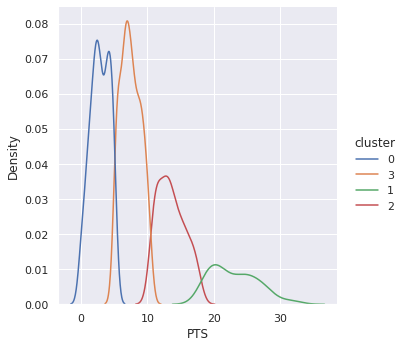

In [17]:
sns.set()
sns.displot(data=df, x='PTS', hue='cluster', kind='kde')

También podemos ver la distribución acumulada de cada cluster pasando el valor de ``'ecdf'`` al parámetro kind.

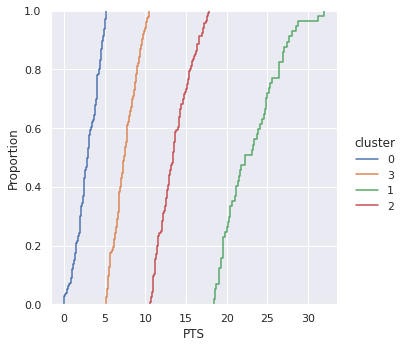

In [18]:
sns.displot(data=df, x='PTS', hue='cluster', kind='ecdf')

Por último podemos realizar un boxplot de cada cluster.

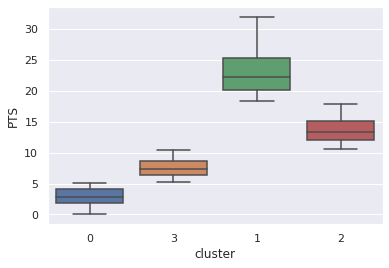

In [19]:
sns.boxplot(data=df, x='cluster', y='PTS');

De esta forma podemos analizar de manera visual los clusters. 

# 5.3. Aplicar Kmeans a dos métricas
Hasta ahora hemos analizado una sola variable y podíamos ver como Kmeans era capaz de extraer el patrón en esa métrica. En el mundo real vamos a tener mas de una variable que analizar. Tenemos que entender que cada columna del dataset representa una dimensión. Ahora pasaremos a analizar dos variables, para ver graficamente, como funcina el clustering y como es posiblre que pueda crear agrupaciones.

Vamos a seguir analizando los bases, ya que por ejemplo podemos encontrar dos tipos de bases, una base más anotador o más pasador. También podemos encontrar lo mejor de ambos mundos, un base anotador y a la vez pasador. Vamos a ver si el algoritmo kmeans es capaz de detectar estos tipos de bases.

Vamos a realizar el mismo procedimiento de siempre a la hora de crear el cluster, pero esta vez vamos a pasarle dos métricas en vez de una. Empezamos con 4 clusters, por tanto 4 diferentes tipos de bases.


In [21]:
cluster = KMeans(n_clusters=4, random_state=1)
df_pg = df[df.Pos == 'PG'].copy()
cluster.fit(df_pg[['PTS', 'AST']])
df_pg['cluster'] = cluster.labels_.astype('str')
df_pg.groupby('cluster')[['PTS', 'AST']].mean().sort_values('AST', ascending=False)

,PTS,AST
cluster,,
2,25.161538,7.507692
0,15.440909,5.545455
3,7.748649,3.075676
1,2.674194,1.087097


Con .groupby() podemos ver las características de cada cluster en función de puntos y asistencias. Pero podemos ver, que con estos 4 clusters, no ha detectado ningún patrón interesante, van a la par, el cluster que más anota también es el que más asistencias hace. Vamos a realizar la visualización y añadir el color en función de cada cluster. 

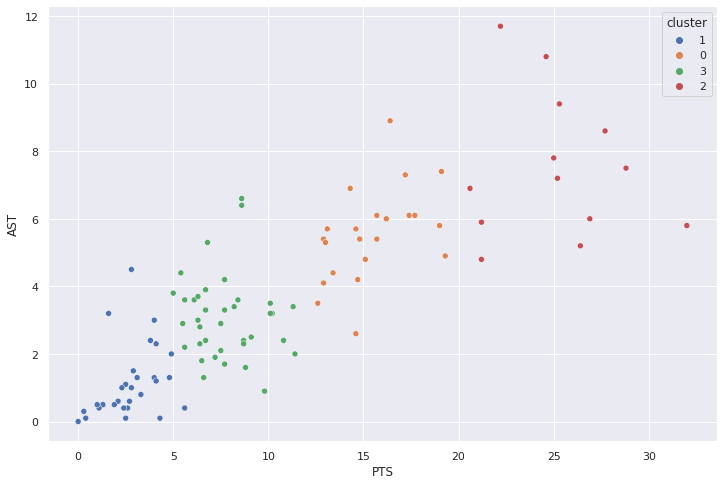

In [22]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_pg, x='PTS', y='AST', hue='cluster')

Podemos observar como el cluster 2 de color rojo, es el cluster de tiene una mayor anortacion y cantida de asistencias, pero si os fijais, hay dispersion en los datos, ya que tiene jugadores mas y menos asistentes. Por tanto vamos a añadir más cantidad de clusters, a ver si el algoritmo es capaz de detectar los diferentes bases que dijimos.

In [24]:
cluster = KMeans(n_clusters=8, random_state=1)
df_pg = df[df.Pos == 'PG'].copy()
cluster.fit(df_pg[['PTS', 'AST']])
df_pg['cluster'] = cluster.labels_.astype('str')
df_pg.groupby('cluster')[['PTS', 'AST']].mean().sort_values('AST', ascending=False)

,PTS,AST
cluster,,
6,24.460000,9.380000
7,28.360000,6.620000
1,18.910000,6.410000
4,14.240000,5.033333
5,7.026087,3.369565
2,9.909091,2.490909
0,4.500000,2.107692
3,1.928571,0.723810


Esto era lo que estábamos buscando, si os fijáis en el cluster 7 y 1, tenemos dos tipos de bases, ambos hacen bastantes asistencias pero uno es más anotador que el otro. También podemos ver en el cluster 6 como es el segundo cluster que más anota pero es el que más asistencias realiza. 

Hagamos de nuevo una visualización de los datos para poder ver mejor la información.


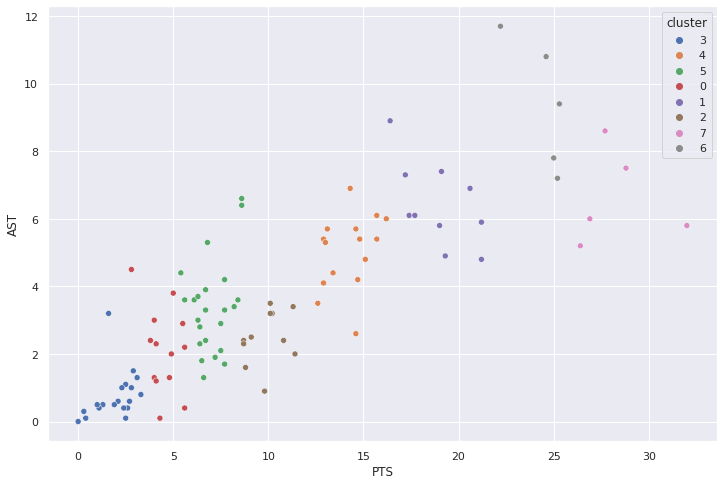

In [25]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_pg, x='PTS', y='AST', hue='cluster')

Podemos ver como el cluster que antes era de color rojo, a pasado a ser dos cluster distintos. Vemos como dentro de los más anotadores, todavía podemos hacer otra agrupación de más asistentes y menos. Kmeans ha sido capaz de detectar ese tipo de comportamiento, sin ni siquiera entender qué es baloncesto. 

Es muy importante el conocimiento del negocio, para sacarle el máximo rendimiento a esta herramienta. Tenemos que saber analizar los clusters que nos devuelve el algoritmo, para ver si tenemos o no que aumentar la cantidad de clusters. Gracias a todo lo aprendido en el curso tenemos las habilidades para poder analizar los cluster y extraer información valiosa de ellos.

Ahora podemos analizar los datos según los clusters y buscar los jugadores que nos interesen, según el tipo de jugador que estamos buscando, como por ejemplo el cluster 7.
 

In [26]:
df_pg[df_pg.cluster == '7']

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
156,Stephen Curry,PG,32,GSW,63,63,34.2,10.4,21.7,0.482,5.3,12.7,0.421,5.1,9.0,0.569,0.605,5.7,6.3,0.916,0.5,5.0,5.5,5.8,1.2,0.1,3.4,1.9,32.0,7
177,Luka Dončić,PG,21,DAL,66,66,34.3,9.8,20.5,0.479,2.9,8.3,0.350,6.9,12.2,0.567,0.550,5.2,7.1,0.730,0.8,7.2,8.0,8.6,1.0,0.5,4.3,2.3,27.7,7
328,Kyrie Irving,PG,28,BRK,54,54,34.9,10.2,20.1,0.506,2.8,7.0,0.402,7.4,13.1,0.561,0.576,3.7,4.0,0.922,1.0,3.8,4.8,6.0,1.4,0.7,2.4,2.6,26.9,7
410,Damian Lillard,PG,30,POR,67,67,35.8,9.0,19.9,0.451,4.1,10.5,0.391,4.9,9.4,0.519,0.554,6.7,7.2,0.928,0.5,3.7,4.2,7.5,0.9,0.3,3.0,1.5,28.8,7
470,Donovan Mitchell,PG,24,UTA,53,53,33.4,9.0,20.6,0.438,3.4,8.7,0.386,5.7,11.9,0.476,0.520,5.0,6.0,0.845,0.9,3.5,4.4,5.2,1.0,0.3,2.8,2.2,26.4,7


También podemos ver el cluster 1, que es el que tiene la misma cantidad de asistencias en promedio, pero en anotación es otro tipo de jugador. 


In [27]:
df_pg[df_pg.cluster == '1']

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
92,Malcolm Brogdon,PG,28,IND,56,56,34.5,7.9,17.5,0.453,2.6,6.7,0.388,5.3,10.8,0.493,0.527,2.7,3.2,0.864,1.0,4.2,5.3,5.9,0.9,0.3,2.1,2.0,21.2,1
227,Darius Garland,PG,21,CLE,54,50,33.1,6.7,14.9,0.451,1.9,4.9,0.395,4.8,9.9,0.479,0.517,2.1,2.4,0.848,0.4,2.0,2.4,6.1,1.2,0.1,3.0,2.0,17.4,1
304,Jrue Holiday,PG,30,MIL,59,56,32.3,7.0,13.9,0.503,1.9,4.8,0.392,5.1,9.2,0.561,0.570,1.8,2.3,0.787,1.2,3.3,4.5,6.1,1.6,0.6,2.2,1.7,17.7,1
418,Kyle Lowry,PG,34,TOR,46,46,34.8,5.7,13.0,0.436,2.8,7.2,0.396,2.8,5.8,0.487,0.546,3.0,3.5,0.875,0.8,4.6,5.4,7.3,1.0,0.3,2.7,3.1,17.2,1
474,Ja Morant,PG,21,MEM,63,63,32.6,6.8,15.2,0.449,1.2,3.8,0.303,5.7,11.4,0.499,0.487,4.3,5.9,0.728,0.9,3.1,4.0,7.4,0.9,0.2,3.2,1.4,19.1,1
481,Jamal Murray,PG,23,DEN,48,48,35.5,7.9,16.5,0.477,2.7,6.6,0.408,5.2,9.9,0.523,0.559,2.8,3.2,0.869,0.8,3.3,4.0,4.8,1.3,0.3,2.3,2.0,21.2,1
529,Chris Paul,PG,35,PHO,70,70,31.4,6.3,12.6,0.499,1.5,3.7,0.395,4.8,8.9,0.543,0.557,2.4,2.6,0.934,0.4,4.1,4.5,8.9,1.4,0.3,2.2,2.4,16.4,1
598,D'Angelo Russell,PG,24,MIN,42,26,28.5,6.7,15.5,0.431,2.9,7.4,0.387,3.8,8.1,0.471,0.523,2.7,3.5,0.765,0.4,2.3,2.6,5.8,1.1,0.4,2.7,1.6,19.0,1
688,Kemba Walker,PG,30,BOS,43,43,31.8,6.6,15.7,0.420,3.0,8.2,0.360,3.7,7.5,0.486,0.514,3.1,3.5,0.899,0.4,3.6,4.0,4.9,1.1,0.3,2.0,1.4,19.3,1
690,John Wall,PG,30,HOU,40,40,32.2,7.3,18.2,0.404,2.0,6.2,0.317,5.4,11.9,0.449,0.458,4.0,5.3,0.749,0.4,2.8,3.2,6.9,1.1,0.8,3.5,1.2,20.6,1


Nuevamente depende del tipo de base que estemos buscando, la combinación de nuestra experiencia, con la combinación de python con el algoritmo Kmeans, nos ayudará a encontrar el tipo de jugador que buscamos. En este caso estamos analizando sólo los jugadores de la NBA, pero podríamos estar analizando una base de datos con miles y miles de jugadores y no podemos estar mirando uno por uno. Es cuando el dominio de estas herramientas se vuelve imprescindible y nos aportará más valor como profesionales.

Vamos  a utilizar Kmeans, para que sea capaz de detectar bases que a la vez que me meten puntos aporta en la parte de rebotes. Pocos bases hacen esa tarea, pero veamos si Kmeans es capaz de localizarlos.


In [28]:
cluster = KMeans(n_clusters=7, random_state=1)
df_pg = df[df.Pos == 'PG'].copy()
cluster.fit(df_pg[['PTS', 'TRB']])
df_pg['cluster'] = cluster.labels_.astype('str')
df_pg.groupby('cluster')[['PTS', 'TRB']].mean().sort_values('TRB', ascending=False)

,PTS,TRB
cluster,,
1,24.875000,8.775000
6,27.433333,4.383333
4,14.375000,4.168750
2,19.188889,3.933333
5,9.520000,2.766667
0,6.368000,2.016000
3,2.414286,0.957143


Podemos ver en el groupby el cluster 1, que contiene a los bases más reboteadores y a al vez el segundo más anotador, por lo que es la combinación perfecta que estamos buscando. 

El cluster 6 y 4 son iguales en cuanto a rebotes pero tienen un patrón distinto de comportamiento en anotación. Veamos la visualización de dichos clusters.


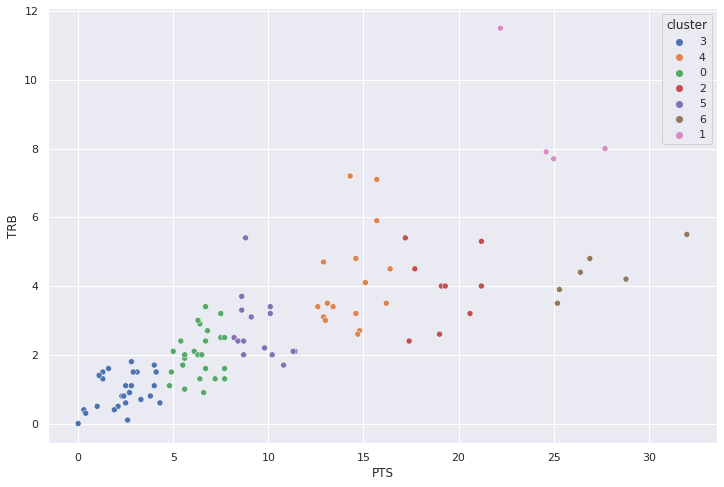

In [29]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_pg, x='PTS', y='TRB', hue='cluster')

Podemos ver visualmente, como dentro de los jugadores más anotadores hay una diferencia entre unos bases más reboteadores que otros, que serían el cluster 1 y 6. Dependiendo del tipo de base te centrarás en un cluster u otro. 

Filtramos los datos para ver qué jugadores son los de cada cluster, primero el cluster más reboteador.


In [30]:
df_pg[df_pg.cluster == '1']

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
177,Luka Dončić,PG,21,DAL,66,66,34.3,9.8,20.5,0.479,2.9,8.3,0.350,6.9,12.2,0.567,0.550,5.2,7.1,0.730,0.8,7.2,8.0,8.6,1.0,0.5,4.3,2.3,27.7,1
266,James Harden,PG,31,TOT,44,43,36.6,7.8,16.7,0.466,2.8,7.6,0.362,5.0,9.1,0.553,0.548,6.3,7.3,0.861,0.8,7.1,7.9,10.8,1.2,0.8,4.0,2.3,24.6,1
340,LeBron James,PG,36,LAL,45,45,33.4,9.4,18.3,0.513,2.3,6.3,0.365,7.1,12.0,0.591,0.576,4.0,5.7,0.698,0.6,7.0,7.7,7.8,1.1,0.6,3.7,1.6,25.0,1
700,Russell Westbrook,PG,32,WAS,65,65,36.4,8.4,19.0,0.439,1.3,4.2,0.315,7.0,14.8,0.475,0.474,4.2,6.4,0.656,1.7,9.9,11.5,11.7,1.4,0.4,4.8,2.9,22.2,1


Ahora miremos el menos reboteador dentro de los más anotadores. 

In [31]:
df_pg[df_pg.cluster == '6']

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
156,Stephen Curry,PG,32,GSW,63,63,34.2,10.4,21.7,0.482,5.3,12.7,0.421,5.1,9.0,0.569,0.605,5.7,6.3,0.916,0.5,5.0,5.5,5.8,1.2,0.1,3.4,1.9,32.0,6
217,De'Aaron Fox,PG,23,SAC,58,58,35.1,9.1,19.1,0.477,1.8,5.5,0.322,7.3,13.6,0.539,0.523,5.2,7.2,0.719,0.6,2.9,3.5,7.2,1.5,0.5,3.0,2.9,25.2,6
328,Kyrie Irving,PG,28,BRK,54,54,34.9,10.2,20.1,0.506,2.8,7.0,0.402,7.4,13.1,0.561,0.576,3.7,4.0,0.922,1.0,3.8,4.8,6.0,1.4,0.7,2.4,2.6,26.9,6
410,Damian Lillard,PG,30,POR,67,67,35.8,9.0,19.9,0.451,4.1,10.5,0.391,4.9,9.4,0.519,0.554,6.7,7.2,0.928,0.5,3.7,4.2,7.5,0.9,0.3,3.0,1.5,28.8,6
470,Donovan Mitchell,PG,24,UTA,53,53,33.4,9.0,20.6,0.438,3.4,8.7,0.386,5.7,11.9,0.476,0.520,5.0,6.0,0.845,0.9,3.5,4.4,5.2,1.0,0.3,2.8,2.2,26.4,6
728,Trae Young,PG,22,ATL,63,63,33.7,7.7,17.7,0.438,2.2,6.3,0.343,5.6,11.3,0.491,0.499,7.7,8.7,0.886,0.6,3.3,3.9,9.4,0.8,0.2,4.1,1.8,25.3,6


# 5.4. La técnica del codo para el número óptimo de clusters 
Hasta ahora hemos estado eligiendo la cantidad de cluster en  base a prueba y error. Existe una técnica matemática que nos dice la cantidad de clusters óptimos. Se le conoce como la técnica del codo, más adelante veremos por qué. Lo que hacemos es calcular la distancia de los puntos al centroide del cluster, que como vimos en la introducción a Kmeans el centroide es el centro geométrico de cada cluster. Empezamos con solo un cluster y se calcula la distancia promedio al cuadrado de todos los puntos al centroide. Cuantos más cluster se añade más se va reduciendo este error. Hasta el punto de que este error será cero si tenemos tantos clusters como puntos. Pero esto ya no tendría sentido porque nosotros buscamos hacer agrupaciones. Por tanto, ¿cuál es la cantidad óptima de clusters? Esto es lo que nos dirá la técnica del codo. 

Vamos a realizar un bucle for para ver como va cambiando ese error a medida que añadimos un cluster y lo graficaremos. Para acceder a ese error utilizaremos el atributo .inertia_


In [32]:
codo = []

for i in range(1,11):
  cluster = KMeans(n_clusters=i, random_state=1)
  cluster.fit(df[['PTS', 'AST']])
  codo.append(cluster.inertia_)

Si miramos la lista codo, veremos los diferentes errores y cómo estos disminuyen a medida que añadimos más clusters.

In [33]:
codo

[24534.62574074074,
 8333.048811872544,
 4365.799020313541,
 2777.5123372731796,
 2092.979631689224,
 1684.7146792612623,
 1450.7643201003705,
 1281.3545655194196,
 1160.533523918531,
 1028.6736584262308]

Vamos  a graficarlo.

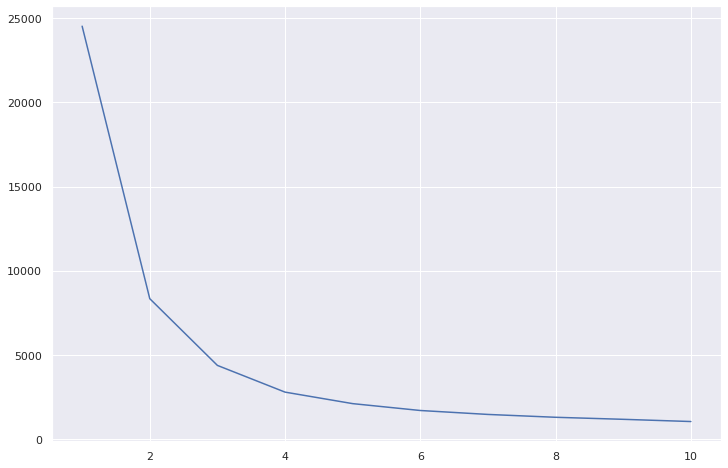

In [34]:
plt.figure(figsize=(12,8))
plt.plot(range(1,11), codo)

Ahora podéis entender porque se le llama la técnica del codo, el gráfico parece un brazo y en el codo es donde supuestamente se encuentra el número óptimo de clusters.Lo que nos dice es que por más cluster que añadamos,no extraemos más información relevante. Esto es lo que dice la teoría matemática. Pero realmente esta técnica no me convence.

Ya he dicho muchas veces la importancia de saber del negocio y este es uno de esos casos, de cómo nuestra experiencia puede mejorar el algoritmo. Ya es algo increíble que un algoritmo que no entiende que es el baloncesto, un pase, los puntos o  que un jugador meta 20 puntos por partido, sea capaz de saber clasificar también a las superestrellas, a los buenos, los normales y no tan buenos. Una vez obtenido los clusters somos nosotros los que tenemos que analizar esos clusters, para saber si necesitamos añadir más o menos. Todo dependerá de los patrones que nos arroje y del tipo de jugador que estemos buscando. 

Como veis, en este caso la técnica del codo, nos está indicando que el número óptimo de clusters es entre 3 y 4. Pero ya vimos que con 4 clusters, con las métricas de puntos y asistencias, no nos aportaba patrones interesantes en el tipo de bases y tuvimos que subir a 8 clusters. Es ahí la importancia de saber entender la información que nos arroja kmeans y ayudarle a mejorar con nuestro conocimiento del negocio.

# 5.5. Crear nuestra propia función para el número óptimo de clusters
Ya hemos visto que necesitamos un mejor enfoque para encontrar el número óptimo de clusters y como ahora somos unos crack de la programación, vamos a beneficiarnos de ello para automatizar el proceso de encontrar el número de  clusters óptimos. Es evidente que depende de lo que busquemos, tendremos que añadir más o menos clusters. 

Lo que queremos que haga nuestra función es que yo pueda probar diferentes clusters, con diferentes variables, ya sea 1, 2, 3, o 20 y que me devuelva el groupby de los clusters, para analizarlos estadísticamente. También quiero una visualización de los datos siempre que se pueda, ya que podemos visualizar de 1 variables, 2 y 3. Más de tres dimensiones no podemos visualizar los datos. 

Por tanto nos apoyaremos en los condicionales para cumplir todas estas posibilidades. También daremos la opción de poder filtrar los datos en función de una posición si así lo queremos.


In [35]:
def explore_cluster(df, n_cluster, cols, pos=None):

  cluster = KMeans(n_clusters=n_cluster, random_state=1)

  if pos != None:
    df[df.Pos == pos]
  
  cluster.fit(df[cols])
  df['cluster'] = cluster.labels_.astype('str')
  df_group = df.groupby('cluster')[cols].mean()

  sns.set()

  if len(cols) == 1:

    plt.figure(figsize=(12,8))
    sns.boxplot(data=df, x='cluster', y=cols[0])

  elif len(cols) == 2:

    plt.figure(figsize=(12,8))
    sns.scatterplot(data=df, x=cols[0], y=cols[1], hue='cluster')

  elif len(cols) == 3:

    fig = px.scatter_3d(df, x=cols[0], y=cols[1], z=cols[2], color='cluster')
    fig.show()

  return df_group, df

En el video que hace referencia a este tema, podremos ver paso a paso el desarrollo de la función.

Una vez creada nuestra función, será tan sencillo como pasarle valores a los parámetro de la función, para empezar a ver resultados. Empezamos con 6 cluster sobre las métricas puntos y asistencias, las métricas las pasaremos por parámetro en formato lista.


(               PTS       AST
 cluster                     
 0        12.745455  2.412121
 1         8.058088  1.945588
 2        25.920690  5.937931
 3         1.959633  0.463303
 4        18.598000  4.328000
 5         4.923077  1.117949,
                 Player Pos  Age   Tm   G  GS  ...  STL  BLK  TOV   PF   PTS  cluster
 0     Precious Achiuwa  PF   21  MIA  61   4  ...  0.3  0.5  0.7  1.5   5.0        5
 1         Jaylen Adams  PG   24  MIL   7   0  ...  0.0  0.0  0.0  0.1   0.3        3
 2         Steven Adams   C   27  NOP  58  58  ...  0.9  0.7  1.3  1.9   7.6        1
 3          Bam Adebayo   C   23  MIA  64  64  ...  1.2  1.0  2.6  2.3  18.7        4
 4    LaMarcus Aldridge   C   35  TOT  26  23  ...  0.4  1.1  1.0  1.8  13.5        0
 ..                 ...  ..  ...  ...  ..  ..  ...  ...  ...  ...  ...   ...      ...
 724       Delon Wright  SG   28  TOT  63  39  ...  1.6  0.5  1.3  1.2  10.2        0
 727     Thaddeus Young  PF   32  CHI  68  23  ...  1.1  0.6  2.0  2.2 

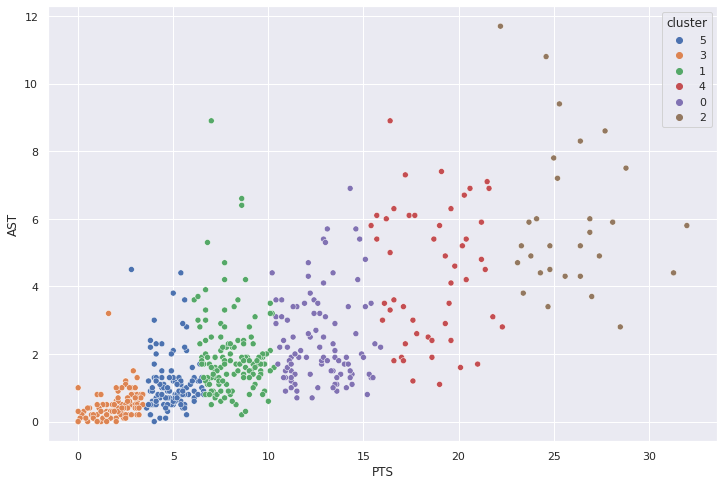

In [36]:
explore_cluster(df, 6, ['PTS', 'AST'])

Como veis la función nos devuelve el dataframe agrupado y el dataframe con la columna de los clusters, según los clusters que le hemos indicado y en función de las métricas indicadas. También obtenemos nuestro gráfico. 

Si os fijais en el return de la función, vemos que estamos devolviendo dos resultaos df_group y df, por eso se ven de la manera que se han visto al ejecutar la función. Para una correcta visualización de los datos lo haremos de la siguiente manera. 

,PTS,AST
cluster,,
0,1.892308,0.453846
1,18.000000,2.608333
2,7.264516,1.453763
3,13.491803,2.380328
4,26.955000,6.110000
5,4.645192,1.002885
6,16.488235,6.141176
7,7.068421,4.363158
8,10.130667,1.932000


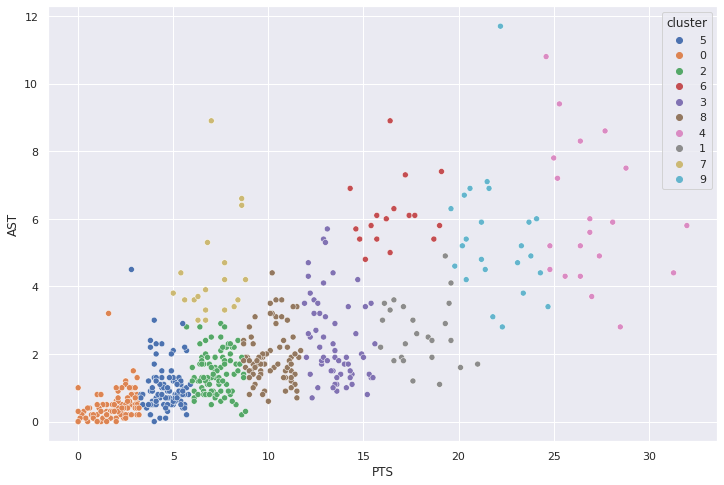

In [37]:
df_group, df_cluster = explore_cluster(df, 10, ['PTS', 'AST'])
df_group

Creamos las variables df_group y df_cluster para que se guarden los dos dataframes que nos devuelve la función. Para la visualización no hace falta hacer nada, automáticamente se mostrará el gráfico sin indicarlo en el return. 

Ahora gracias a nuestra automatización vamos a indicar 10 cluster sobre los puntos y asistencias y filtraremos los datos para los bases,  indicando 'PG' por parámetro. 

,PTS,AST
cluster,,
0,1.892308,0.453846
1,18.000000,2.608333
2,7.264516,1.453763
3,13.491803,2.380328
4,26.955000,6.110000
5,4.645192,1.002885
6,16.488235,6.141176
7,7.068421,4.363158
8,10.130667,1.932000


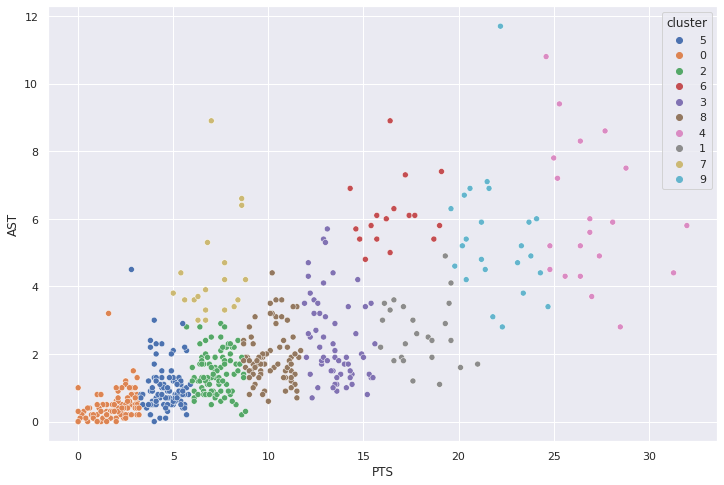

In [38]:
df_group, df_cluster = explore_cluster(df, 10, ['PTS', 'AST'], 'PG')
df_group

Ahora tenemos una manera más efectiva de probar e investigar los clusters en función de  nuestras necesidades y lo que estemos buscando.

Vamos a probar nuestra función con 3 variables, que nos devolverá el gráfico en 3D.


In [39]:
df_group, df_cluster = explore_cluster(df, 14, ['PTS', 'AST','TRB'])
df_group

,PTS,AST,TRB
cluster,,,
0,12.963333,2.893333,3.426667
1,5.779167,1.064583,4.185417
10,6.945763,2.225424,2.461017
11,14.271429,1.457143,11.971429
12,24.322222,7.277778,10.377778
13,16.350000,6.187500,4.350000
2,21.047826,4.765217,5.721739
3,1.654762,0.395238,1.026190
4,8.194872,1.707692,6.341026


Gracias a nuestra función, podemos buscar clusters de tantas métricas como queramos, eso sí el resultado de salida solo será el dataframe agrupado y el dataframe, ya que no podemos realizar visualización de más de 3 variables numéricas. 


In [40]:
df_group, df_cluster = explore_cluster(df, 6, ['PTS', 'AST','TRB','2P', '3P'])
df_group

,PTS,AST,TRB,2P,3P
cluster,,,,,
0,6.181481,1.474691,3.380864,1.607407,0.705556
1,17.432727,4.134545,4.581818,4.225455,2.147273
2,10.580198,2.351485,3.655446,2.309901,1.526733
3,25.044444,5.694444,6.944444,6.744444,2.155556
4,2.417857,0.580714,1.385000,0.577857,0.302857
5,12.173913,1.808696,7.610870,4.039130,0.756522


Podremos analizar la información que queremos y buscar los patrones que a nosotros nos interese, gracias a la versatilidad de la función. 

# 5.6. Encontrar jugadores similares
Del cluster anterior en donde obtuvimos  6 clusters en función de los puntos, asistencias, rebotes, tiros de dos y de tres, obtuvimos un dataframe con la columna cluster en función de este análisis. Ahora por ejemplo, podríamos filtrar los datos en función de un jugador.


In [41]:
df_cluster[df_cluster.Player == 'Steven Adams']

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
2,Steven Adams,C,27,NOP,58,58,27.7,3.3,5.3,0.614,0.0,0.1,0.0,3.3,5.3,0.62,0.614,1.0,2.3,0.444,3.7,5.2,8.9,1.9,0.9,0.7,1.3,1.9,7.6,5


El filtrado lo hacemos para ver a qué cluster pertenece, para entonces ahora filtrar los datos en función a ese cluster y ver los jugadores que se encuentran en ese mismo cluster, para poder  buscar un jugador similar.

In [42]:
df_cluster[df_cluster.cluster == '5']

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,cluster
2,Steven Adams,C,27,NOP,58,58,27.7,3.3,5.3,0.614,0.0,0.1,0.000,3.3,5.3,0.620,0.614,1.0,2.3,0.444,3.7,5.2,8.9,1.9,0.9,0.7,1.3,1.9,7.6,5
4,LaMarcus Aldridge,C,35,TOT,26,23,25.9,5.4,11.4,0.473,1.2,3.1,0.388,4.2,8.3,0.505,0.525,1.6,1.8,0.872,0.7,3.8,4.5,1.9,0.4,1.1,1.0,1.8,13.5,5
10,Jarrett Allen,C,22,TOT,63,45,29.6,4.7,7.7,0.618,0.1,0.3,0.316,4.6,7.3,0.631,0.624,3.2,4.6,0.703,3.1,6.9,10.0,1.7,0.5,1.4,1.6,1.5,12.8,5
16,Kyle Anderson,PF,27,MEM,69,69,27.3,4.5,9.5,0.468,1.4,3.8,0.360,3.1,5.8,0.539,0.540,2.1,2.7,0.783,0.8,5.0,5.7,3.6,1.2,0.8,1.2,1.7,12.4,5
30,Deandre Ayton,C,22,PHO,69,69,30.7,6.2,10.0,0.626,0.1,0.3,0.200,6.2,9.7,0.639,0.629,1.9,2.5,0.769,3.3,7.2,10.5,1.4,0.6,1.2,1.5,2.8,14.4,5
33,Marvin Bagley III,PF,21,SAC,43,42,25.9,5.7,11.4,0.504,0.9,2.5,0.343,4.9,8.9,0.550,0.542,1.8,3.1,0.575,2.5,4.9,7.4,1.0,0.5,0.5,1.4,2.3,14.1,5
45,Darius Bazley,PF,20,OKC,55,55,31.2,5.0,12.5,0.396,1.5,5.2,0.290,3.5,7.3,0.470,0.456,2.3,3.2,0.702,0.9,6.3,7.2,1.8,0.5,0.5,2.2,1.1,13.7,5
74,Chris Boucher,C,28,TOR,60,14,24.2,4.8,9.3,0.514,1.5,3.9,0.383,3.3,5.4,0.609,0.595,2.5,3.2,0.788,2.0,4.8,6.7,1.1,0.6,1.9,0.8,2.8,13.6,5
89,Miles Bridges,PF,22,CHO,66,19,29.3,4.7,9.4,0.503,1.8,4.4,0.400,3.0,5.0,0.593,0.596,1.5,1.7,0.867,1.2,4.8,6.0,2.2,0.7,0.8,1.6,2.2,12.7,5
98,Moses Brown,C,21,OKC,43,32,21.4,3.4,6.2,0.545,0.0,0.0,NaN,3.4,6.2,0.545,0.545,1.8,2.9,0.619,3.6,5.3,8.9,0.2,0.7,1.1,1.0,2.2,8.6,5


De esta manera tenemos una lista de jugadores similares a Steven Adams, pero recuerda, esta similitud ha sido en base a unas métricas y 6 clusters, es nuestro trabajo analizar los datos de salida para ver la cantidad de  clusters adecuados. 

# 5.6. Utilizar nuestra función en los datos de fútbol
Nuestra función es lo bastante flexible, para poder aplicarla a otros tipos de datos como de otro deporte, solo hay un inconveniente, en si quisiéramos filtrar los datos en torno a una posición y es que la función, está hecha para la columna 'Pos' de Basketball Reference. Pero si no utilizamos el parámetro pos de la función, podemos utilizar cualquier dataframe de cualquier deporte. Si quisiéramos filtrar los datos en cuanto a una posición tendremos que pasar el dataframe ya filtrado a la función.

Vamos a importar  datos de fútbol, utilizaremos los  datos de FBref de la carpeta fbref del curso.


In [43]:
df = pd.read_csv('/content/drive/MyDrive/Mi curso/Data/fbref/fbref_all_players_21_standard_stats.csv')
df.head()

,player,nation,pos,squad,age,born,mp,starts,min,90s,gls,ast,g-pk,pk,pkatt,crdy,crdr,gls/90,ast/90,g+a,g-pk/90,g+a-pk,xg,npxg,xa,npxg+xa,xg/90,xa/90,xg+xa,npxg/90,npxg+xa/90
0,Sabit Abdulai,GHA,MF,Getafe,21,1999,3,0,60,0.7,0,0,0,0,0,1,0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00
1,Marcos Acuña,ARG,DF,Sevilla,28,1991,30,26,2330,25.9,1,2,1,0,0,5,0,0.04,0.08,0.12,0.04,0.12,1.1,1.1,2.8,4.0,0.04,0.11,0.15,0.04,0.15
2,Bobby Adekanye,NED,FW,Cádiz,21,1999,3,0,36,0.4,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.2,0.2,0.0,0.2,0.43,0.00,0.43,0.43,0.43
3,Martin Agirregabiria,ESP,DF,Alavés,24,1996,26,16,1558,17.3,0,1,0,0,0,1,0,0.00,0.06,0.06,0.00,0.06,0.2,0.2,0.9,1.1,0.01,0.05,0.06,0.01,0.06
4,Joseph Aidoo,GHA,DF,Celta Vigo,24,1995,25,14,1289,14.3,0,0,0,0,0,3,0,0.00,0.00,0.00,0.00,0.00,0.8,0.8,0.6,1.4,0.06,0.04,0.10,0.06,0.10


Por ejemplo, busquemos 5 tipos de jugadores distintos en función de los goles y asistencias.

,gls,ast
cluster,,
0,3.897436,1.487179
1,0.364066,0.335697
2,22.000000,5.000000
3,1.745098,4.745098
4,10.125000,4.416667


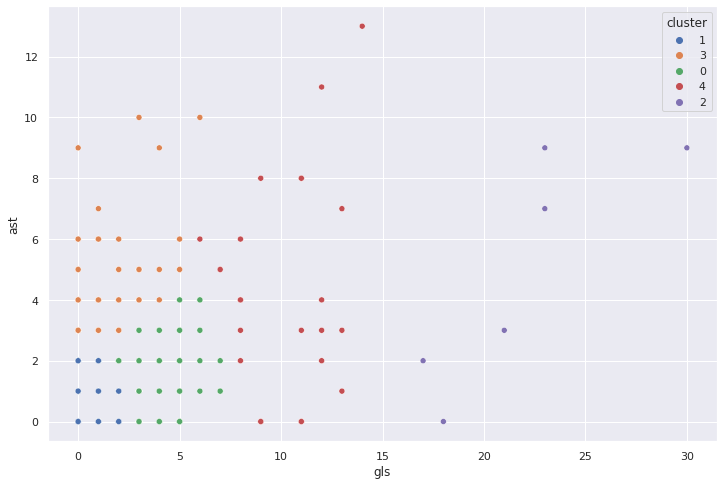

In [44]:
df_group, df_cluster = explore_cluster(df, 5, ['gls', 'ast'])
df_group

Nuevamente vemos el poder que nos otorga la programación y el dominio de Python. 

Vamos a mirar un último ejemplo más, utilizando solo una metrica para ver el tipo de gráfico. Vamos a buscar 5 tipos diferentes de jugadores en función del xG


,xg
cluster,
0,1.745985
1,7.854545
2,16.010000
3,0.266854
4,4.570175


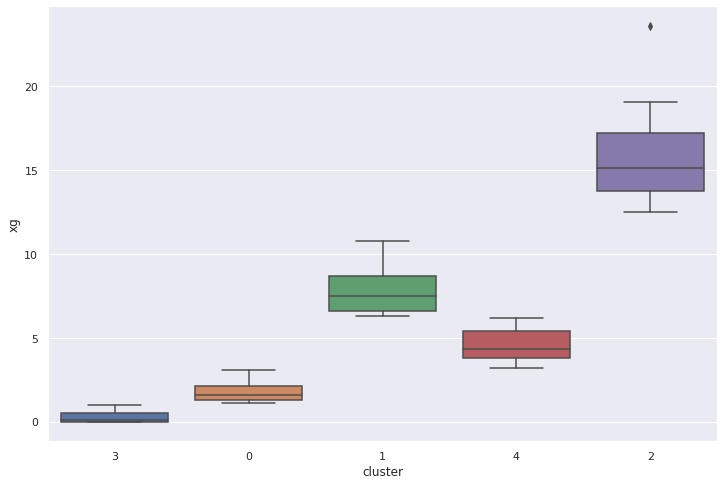

In [45]:
df_group, df_cluster = explore_cluster(df.fillna(0), 5, ['xg'])
df_group

Vemos lo versátil que es nuestra función. 
# 5.7. Utilizar todas las columnas numéricas de un dataframe
Hasta ahora hemos analizado de 1 a 3 variables, pero podemos usar todas las columnas del dataframe para realizar los clusters. Es importante saber que no se le puede pasar una columna categórica a un algoritmo de Machine Learning, solo funcionan con columnas numéricas. 

Vamos a ver una sencilla manera de como obtener todas las columnas numéricas del dataframe y evitarnos coger las categóricas de manera automática. Tenemos la función ._get_numeric_data() que se encarga de dejarnos el dataframe con solo las columnas numéricas. 


In [46]:
df_num = df._get_numeric_data()
df_num.columns

Index(['age', 'born', 'mp', 'starts', 'min', '90s', 'gls', 'ast', 'g-pk', 'pk',
       'pkatt', 'crdy', 'crdr', 'gls/90', 'ast/90', 'g+a', 'g-pk/90', 'g+a-pk',
       'xg', 'npxg', 'xa', 'npxg+xa', 'xg/90', 'xa/90', 'xg+xa', 'npxg/90',
       'npxg+xa/90'],
      dtype='object')

Como vemos solo tenemos columnas numéricas, ya no aparece ni 'player',  ni 'team', ni 'pos'. Por tanto lo que haremos, será pasar todas las columnas numéricas de este dataframe que  solo contiene columnas numéricas, a través de .columns como parámetro a nuestra función. 

In [47]:
df_group, df_cluster = explore_cluster(df.fillna(0), 5, df_num.columns)
df_group

,age,born,mp,starts,min,90s,gls,ast,g-pk,pk,pkatt,crdy,crdr,gls/90,ast/90,g+a,g-pk/90,g+a-pk,xg,npxg,xa,npxg+xa,xg/90,xa/90,xg+xa,npxg/90,npxg+xa/90
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,27.635417,1992.083333,33.739583,32.020833,2807.218750,31.193750,3.364583,2.281250,2.885417,0.479167,0.635417,5.541667,0.250000,0.108750,0.073958,0.183333,0.093021,0.167396,3.170833,2.684375,2.143750,4.833333,0.103021,0.069375,0.172396,0.087292,0.156250
1,25.931034,1993.741379,15.758621,7.172414,705.327586,7.839655,0.793103,0.594828,0.741379,0.051724,0.060345,1.913793,0.060345,0.102328,0.069741,0.171638,0.097069,0.166466,0.915517,0.869828,0.600862,1.465517,0.114655,0.075690,0.190776,0.109914,0.185948
2,26.824561,1992.859649,23.719298,15.017544,1356.938596,15.078947,1.587719,1.131579,1.438596,0.149123,0.210526,3.289474,0.140351,0.103070,0.074737,0.178158,0.093158,0.168333,1.683333,1.524561,1.087719,2.616667,0.110439,0.073070,0.182807,0.099912,0.172456
3,23.375839,1996.335570,4.503356,1.228188,138.187919,1.534899,0.114094,0.114094,0.087248,0.026846,0.026846,0.442953,0.046980,0.047450,0.063893,0.111342,0.027584,0.091477,0.171812,0.151007,0.075839,0.230201,0.124027,0.051275,0.175034,0.108926,0.159933
4,26.953271,1992.794393,29.579439,23.915888,2093.775701,23.260748,2.887850,1.887850,2.588785,0.299065,0.420561,4.691589,0.196262,0.120748,0.079720,0.201215,0.107757,0.188224,2.799065,2.472897,1.882243,4.349533,0.118785,0.080093,0.198411,0.104579,0.184019


De esta manera obtenemos un groupby de todas las columnas. Ahora tenemos más información de cada cluster, tendremos que analizar mejor los cluster para ver qué tipo de jugador esconde cada cluster.